In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("all_data.csv")
df = df.iloc[:, 1:]

In [59]:
#df = df[df["pure_application"]]
df = df.groupby(["episode_number", "type", "n", "frequency", "model"]).mean().reset_index()
df["Task"] = df["type"].apply(lambda x: "Generalize" if x == "generalize" else "Copy")
df["Percent correct per grammar"] = df["correct"]
df["Number of repeated arguments"] = df["n"]
df["Frequency"] = np.log(df["frequency"] + 1)


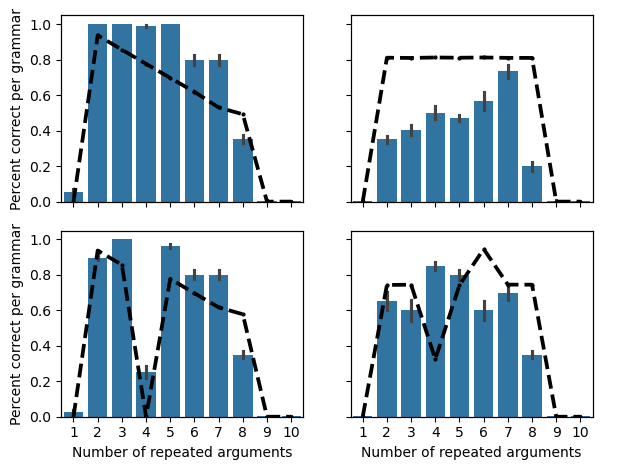

In [62]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
idx = {'few-four.pt': (1, 1), 'no-four_alt.pt': (1,0), 'replication.pt': (0,0), 'uniform.pt':(0,1)}

for value, group in df.groupby("model"):
    i = idx[value]
    sns.barplot(
    data=group,
    x="Number of repeated arguments",
    y="Percent correct per grammar",
    #hue="model",
    errorbar="ci",
    legend=False,
    ax=axs[i[0], i[1]]
)
    
    ax2 = axs[i[0], i[1]].twinx()
    ax2.grid(False)
    sns.pointplot(
        data=group,
        x="Number of repeated arguments",
        y="Frequency",
        ax=ax2,
        color="black",
        linestyle="--",
        label="Frequency in the train set",
        markersize=1,
        legend=False
    )
    ax2.yaxis.set_tick_params(labelcolor='none', color='none')
    ax2.set_ylabel("")
    ax2.set_ylim(0, 12)

fig.tight_layout()
fig.savefig("all.eps")

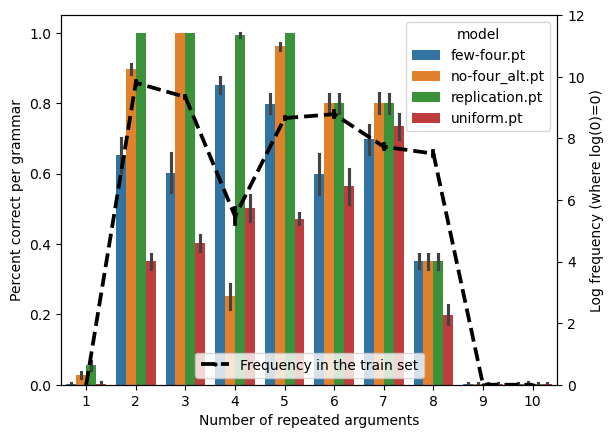

In [37]:

ax = 